In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import leafmap

In [2]:
# buat datanya
data = {
    "Name": ["New York City", "São Paulo", "Tokyo", "Lagos", "Sydney"],
    "Population": [8419600, 12325232, 13929286, 15000000, 5312163],  # Approximate populations
    "Latitude": [40.7128, -23.5505, 35.6895, 6.5244, -33.8688],
    "Longitude": [-74.0060, -46.6333, 139.6917, 3.3792, 151.2093]
}


In [3]:
cities_df = pd.DataFrame(data)

In [4]:
gdf = gpd.GeoDataFrame(
    cities_df,
    geometry=gpd.points_from_xy(
        cities_df['Longitude'],
        cities_df['Latitude']
    )

)

<Axes: >

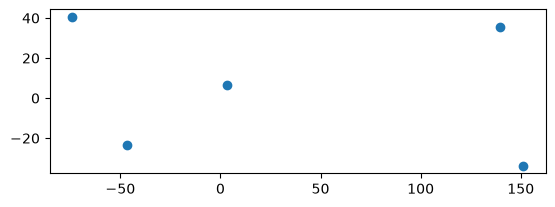

In [5]:
gdf.plot()

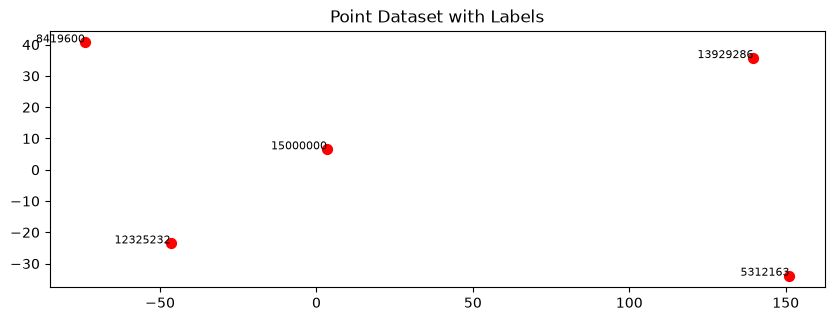

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='red', markersize=50)
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["Population"]):
    ax.text(x, y, label, fontsize=8, color='black', ha='right')
plt.title("Point Dataset with Labels")
plt.show()

In [7]:
gdf = gdf.set_crs(epsg=4326)

In [8]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
gdf.explore()

In [10]:
m = leafmap.Map(center=[0,0], zoom=2)

In [11]:
m

Map(center=[0, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text'…

In [12]:
m.add_gdf(gdf, layer_name="Points")

In [13]:
m.add_basemap("Esri.WorldImagery") #satelit
m.add_basemap("OpenStreetMap") #openstreet

OpenStreetMap has been already added before.


In [14]:
gdf.head()

,Name,Population,Latitude,Longitude,geometry
0,New York City,8419600,40.7128,-74.0060,POINT (-74.006 40.7128)
1,São Paulo,12325232,-23.5505,-46.6333,POINT (-46.6333 -23.5505)
2,Tokyo,13929286,35.6895,139.6917,POINT (139.6917 35.6895)
3,Lagos,15000000,6.5244,3.3792,POINT (3.3792 6.5244)
4,Sydney,5312163,-33.8688,151.2093,POINT (151.2093 -33.8688)
